In [5]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))
from notebook_setup import *

# Aggrégation du fichier réclamations

Ici se trouve l'analyse exploratoire et la démarche détaillée ayant menée à l'agrégation du fichier réclamations

In [6]:
#Librairies and file loading 

import pandas as pd
from src.utils.Visualisation import plot_hist_top_k
import matplotlib.pyplot as plt
from src.data_processing.data_load import data_loading

# Load réclamations data using the data_load function
consommations, impayes, interactions, portefeuille, reclamations = data_loading("training")
df_reclamations = reclamations

c:\Users\kelly\BDC-Alptis\src\data_processing\data_load.py:19: DtypeWarning: Columns (0: client_nps_date_reponse_n_moins1, 1: client_nps_verbatim_n_moins1) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frames[key] = pd.read_csv(filepath, sep=";")


In [7]:
print(len(df_reclamations.columns))
print(len(df_reclamations))
df_reclamations.columns

12
11045


Index(['client_code', 'recla_date_reception', 'recla_date_cloture',
       'recla_initiateur', 'recla_motif_acpr', 'recla_motif', 'recla_theme',
       'recla_canal_entrant', 'recla_solution_trouvee',
       'recla_reponse_gestion', 'recla_est_sensible',
       'recla_motif_sensibilite'],
      dtype='str')

In [8]:
df_reclamations.head()

,client_code,recla_date_reception,recla_date_cloture,recla_initiateur,recla_motif_acpr,recla_motif,recla_theme,recla_canal_entrant,recla_solution_trouvee,recla_reponse_gestion,recla_est_sensible,recla_motif_sensibilite
0,7123579,2022-12-17,2022-12-21,Client,Gestion du contrat,Couverture et fonctionnement de la garantie,APPLICATION DU CONTRAT,Formulaire web,Positive,Oui,0,NaN
1,7171011,2022-12-22,2022-12-28,Client,Gestion du contrat,Valeur non référencée,NaN,Formulaire web,Positive,Oui,0,NaN
2,7264622,2022-12-27,2023-01-02,Client,Gestion du contrat,Délai de traitement,NaN,Formulaire web,Positive,Oui,0,NaN
3,7282990,2022-12-01,2022-12-04,Client,Gestion du contrat,Couverture et fonctionnement de la garantie,APPLICATION DU CONTRAT,Formulaire web,Positive,Oui,0,NaN
4,7324752,2022-12-06,2022-12-06,Client,Gestion du contrat,Demandes de compléments / pièces,QUALITE DE TRAITEMENT,Formulaire web,Positive,Oui,0,NaN


In [9]:
num_cols = df_reclamations.select_dtypes(include=["number"]).columns
cat_cols = df_reclamations.select_dtypes(exclude=["number"]).columns

df_reclamations[cat_cols].describe()

,recla_date_reception,recla_date_cloture,recla_initiateur,recla_motif_acpr,recla_motif,recla_theme,recla_canal_entrant,recla_solution_trouvee,recla_reponse_gestion,recla_motif_sensibilite
count,11045,10824,11045,11045,11029,8705,11045,10824,10824,147
unique,363,301,5,5,16,5,6,2,2,8
top,2023-11-28,2023-07-27,Client,Sinistre / Prise en charge,Couverture et fonctionnement de la garantie,APPLICATION DU CONTRAT,Formulaire web,Positive,Oui,Menace saisie d'un tiers
freq,88,80,9908,7114,2291,4781,7638,9202,10496,43


In [10]:

df_reclamations[num_cols].describe()

,client_code,recla_est_sensible
count,1.104500e+04,11045.000000
mean,1.358020e+07,0.013309
std,3.072949e+06,0.114600
min,2.364700e+04,0.000000
25%,1.288139e+07,0.000000
50%,1.499028e+07,0.000000
75%,1.548541e+07,0.000000
max,1.619278e+07,1.000000


Après analyse rapide, le fichier réclamation est constitué de: 
- 12 colonnes
- 11045 lignes, 1 ligne par date de réclamation: *recla_date_reception*

In [11]:
#pour un client_code on peut avoir plusieurs réclamations
#  selon la date de reception de la réclamation
df_reclamations[df_reclamations["client_code"]==7171011]

,client_code,recla_date_reception,recla_date_cloture,recla_initiateur,recla_motif_acpr,recla_motif,recla_theme,recla_canal_entrant,recla_solution_trouvee,recla_reponse_gestion,recla_est_sensible,recla_motif_sensibilite
1,7171011,2022-12-22,2022-12-28,Client,Gestion du contrat,Valeur non référencée,NaN,Formulaire web,Positive,Oui,0,NaN
704,7171011,2023-01-19,2023-01-22,Client,Sinistre / Prise en charge,Délai de traitement,NaN,Formulaire web,Positive,Oui,0,NaN
705,7171011,2023-02-10,2023-02-21,Client,Gestion du contrat,Conditions particulières de souscription,APPLICATION DU CONTRAT,Formulaire web,Négative,Non,0,NaN
706,7171011,2023-02-10,2023-02-26,Client,Sinistre / Prise en charge,Délai de traitement,NaN,Formulaire web,Négative,Non,0,NaN
707,7171011,2023-02-10,2023-03-23,Client,Sinistre / Prise en charge,Demandes de compléments / pièces,QUALITE DE TRAITEMENT,Formulaire web,Positive,Oui,0,NaN


### Analyse des thèmes/motifs de réclamations 

In [12]:
df_reclamations["recla_theme"].value_counts()

recla_theme
APPLICATION DU CONTRAT    4781
TARIF & FRAIS             2095
QUALITE DE TRAITEMENT     1483
EXTERNE                    275
QUALITE RELATIONNELLE       71
Name: count, dtype: int64

TypeError: 'value' must be an instance of str or bytes, not a float

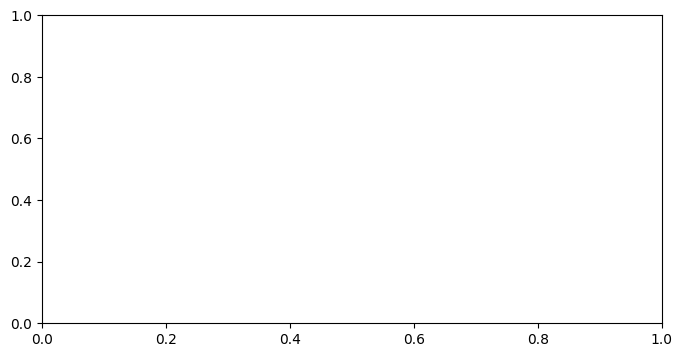

In [13]:
plot_hist_top_k(df_reclamations, ["recla_theme"], k=5)

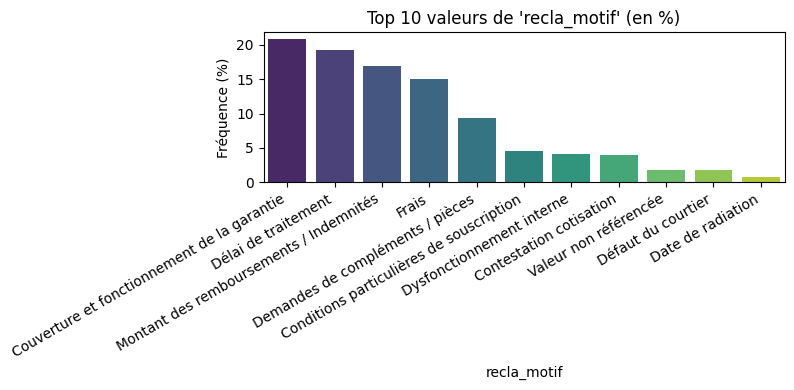

In [ ]:
plot_hist_top_k(df_reclamations, ["recla_motif"], k=10)

Valeurs pour recla_theme = APPLICATION DU CONTRAT


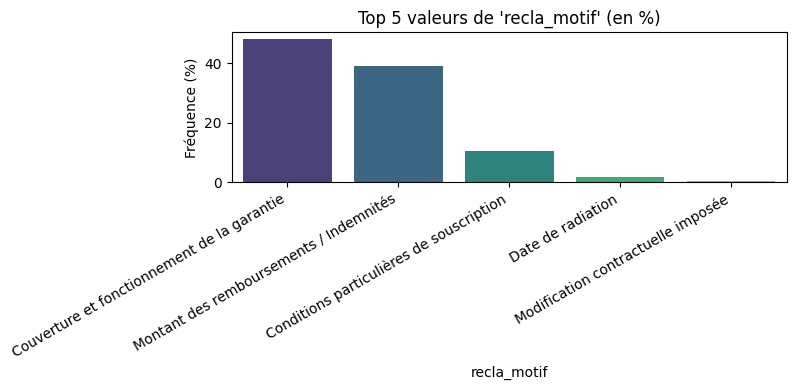

Valeurs pour recla_theme = nan


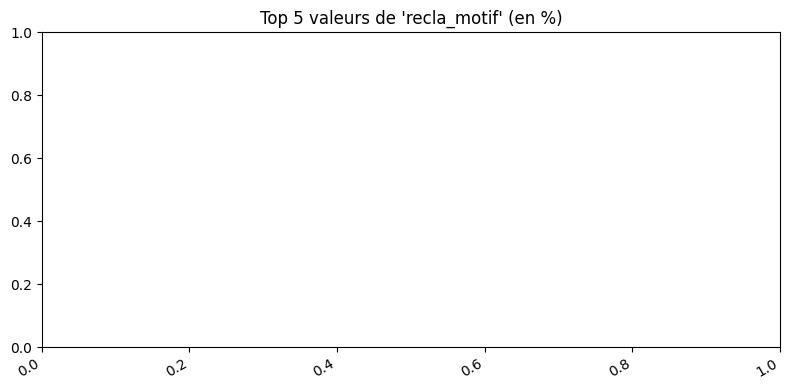

Valeurs pour recla_theme = QUALITE DE TRAITEMENT


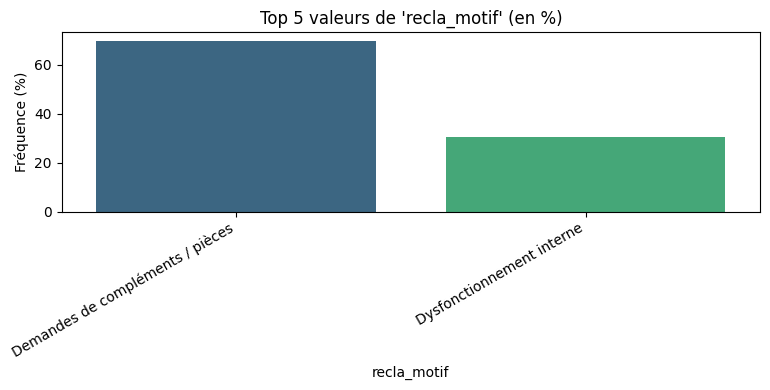

Valeurs pour recla_theme = TARIF & FRAIS


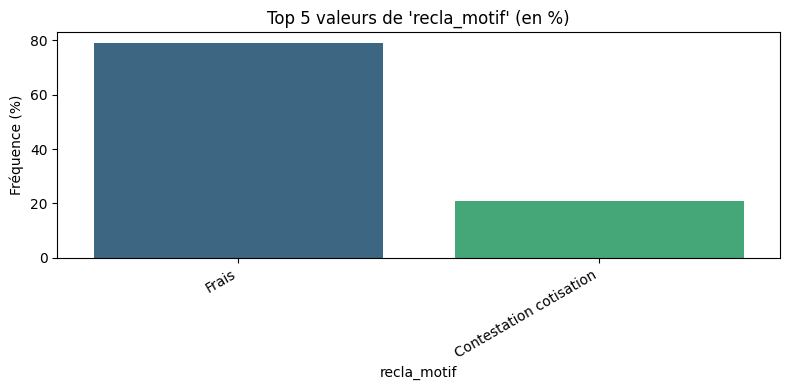

Valeurs pour recla_theme = EXTERNE


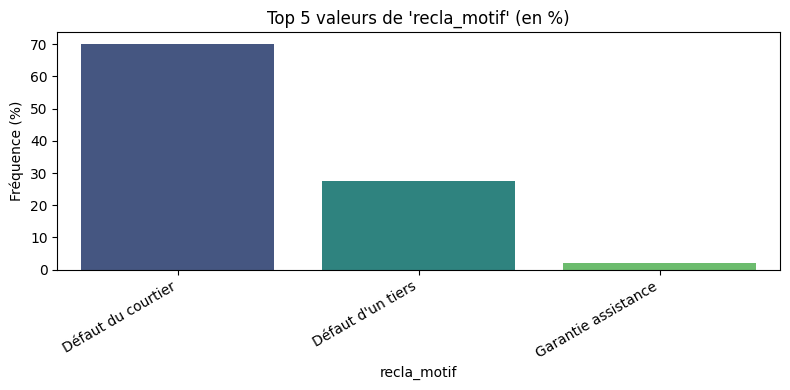

Valeurs pour recla_theme = QUALITE RELATIONNELLE


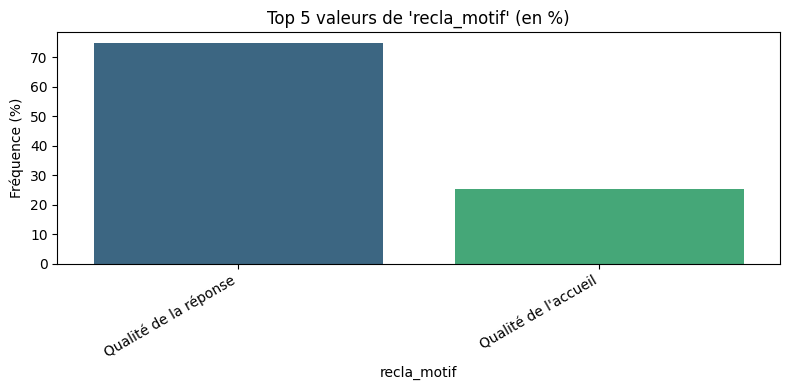

In [ ]:
#Analyse des motifs par thème de réclamation
for theme in df_reclamations["recla_theme"].unique(): 
    print(f"Valeurs pour recla_theme = {theme}")
    plot_hist_top_k(df_reclamations[df_reclamations["recla_theme"]== theme], ["recla_motif"], k=5)

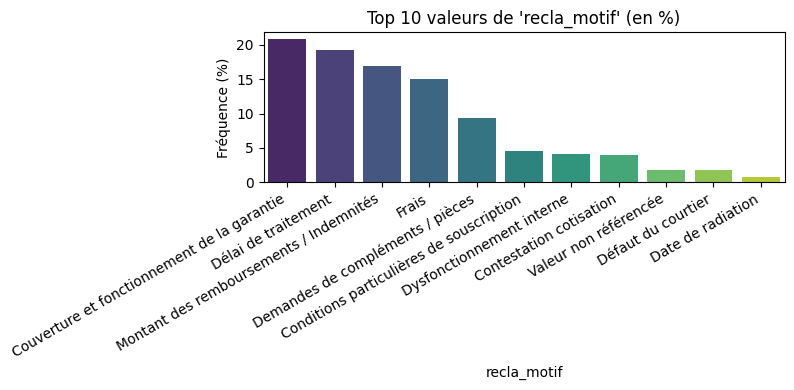

In [ ]:
plot_hist_top_k(df_reclamations, ["recla_motif"], 10)

Les colonnes les plus importantes pour notre analyse sur le fichier des réclamations: 
- *recla_theme* sujet général de la réclamation, il y en a 5 possibles
- *recla_motif* qui est le motif plus détaillé de la réclamation (découle de *recla_theme* selon classification interne), il y en a au plus 5 possibles pour chaque *recla_theme*
On remarque que 5 motifs dominent sur le portefeuille de client. On pourra ainsi créer une variable indicatrice par motif de réclamation sur chacun des 5 motifs principaux, ainsi qu'une colonne *recla_motif_autre* regroupant tous les autres motifs. Ainsi, chacun de ces colonnes dans le dataframe agrégé comptera le nombre de réclamations faites pour chacun des 5 motifs principaux (ou autre motif) pour un même client, sur l'année.


### Analyse des canaux de communication

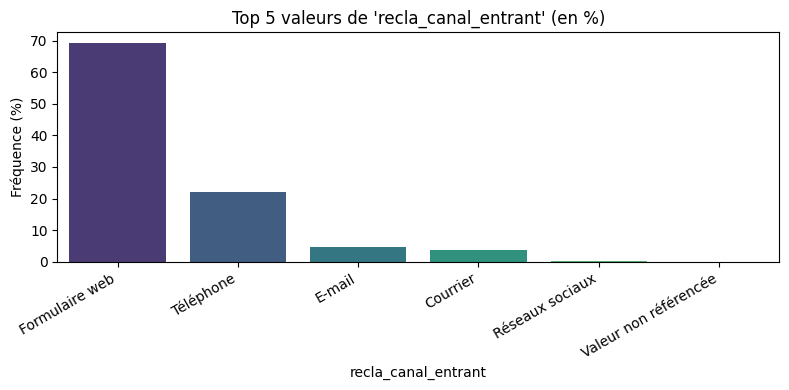

In [ ]:
plot_hist_top_k(df_reclamations, ["recla_canal_entrant"], k=5)

In [ ]:
#Un client est souvent associé à un type de canal particulier

nb_clients_multicanaux = (
    df_reclamations.groupby("client_code")["recla_canal_entrant"]
      .nunique()                   # nombre de canaux différents
      .gt(1)                       # True si >1
      .sum()                       # compte les True
)
print("Nbre clients sur >1 canal :", nb_clients_multicanaux)

pureté = (
    df_reclamations.groupby("client_code")["recla_canal_entrant"]
      .agg(lambda x: x.value_counts(normalize=True).max()))
print(f"Pureté du canal entrant par client: {pureté.mean().round(2)}")

Nbre clients sur >1 canal : 608
Pureté du canal entrant par client: 0.96


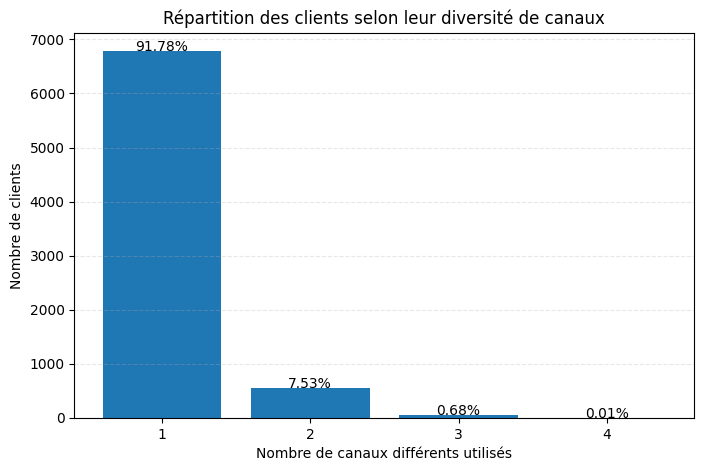

In [ ]:

nb_canaux_par_client = (
    df_reclamations.groupby("client_code")["recla_canal_entrant"]
    .nunique()
)
repartition = nb_canaux_par_client.value_counts().sort_index()
pourcentage = (repartition / nb_canaux_par_client.shape[0] * 100).round(2)

plt.figure(figsize=(8,5))
plt.bar(repartition.index.astype(str), repartition.values)

# Ajouter les pourcentages au-dessus des barres
for idx, (x, y) in enumerate(zip(repartition.index, repartition.values)):
    plt.text(x-1, y , f"{pourcentage.loc[x]}%", ha="center")

plt.xlabel("Nombre de canaux différents utilisés")
plt.ylabel("Nombre de clients")
plt.title("Répartition des clients selon leur diversité de canaux")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()


On pourra retenir les deux canaux principaux de communication pour chaque ligne client_code, étant donné que les clients sont majoritairement présents sur un seul type de canal, voire deux pour 8% des clients.

### Analyse de l'initiateur

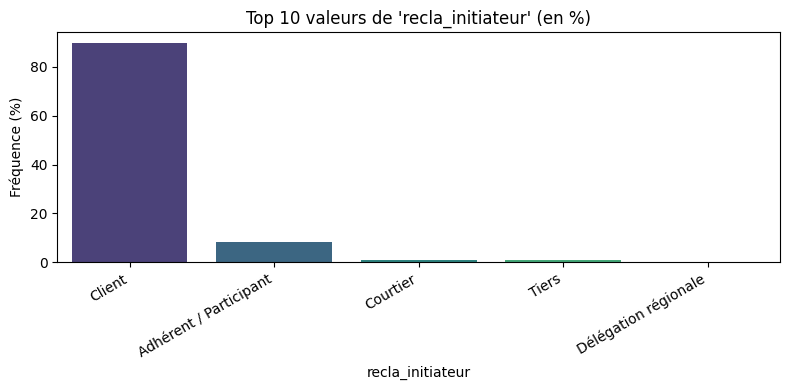

In [ ]:
plot_hist_top_k(df_reclamations, ["recla_initiateur"], k=10)

L'initiateur est soit le client, soit l'adhérent/participant (sûrement un adhérent du contrat qui est pas le client lui-même, par exemple conjoint ou enfant). Dans tous les cas, l'initiative est presque toujours côté client.
On pourra considérer qu'une réclamation adhérent/Participant correspond à une réclamation Client. 

La colonne *recla_initiateur* peut-être transformée en boolean nommée *recla_initiateur_client* qui vaut 1 si la réclamation vient d'un adhérent/participant ou du client lui-même et 0 sinon. 
Ensuite, on agrégera le fichier, en sommant les valeurs sur cette nouvelle colonne *recla_initiateur_client*, ainsi la colonne * recla_initiateur_client* du fichier agrégé compte le nombre de réclamations initiées du côté client (par le client lui-même ou un adhérent)

### Analyse des dates de clôture/réception 

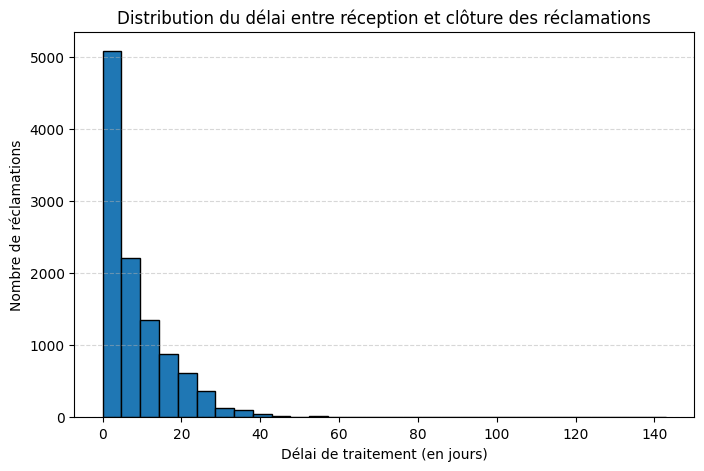

<Figure size 1000x500 with 0 Axes>

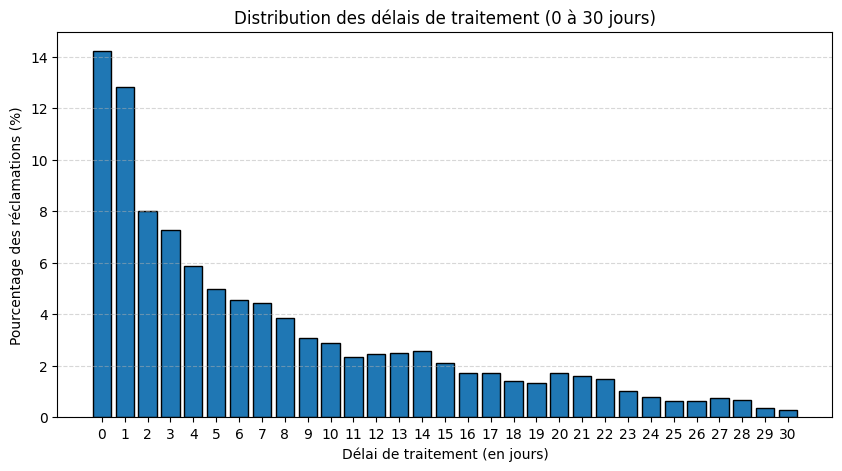

In [ ]:
#Conversion en datetime
df_reclamations["recla_date_cloture"] = pd.to_datetime(df_reclamations["recla_date_cloture"])
df_reclamations["recla_date_reception"] = pd.to_datetime(df_reclamations["recla_date_reception"])

#Calcul des délais de traitement dans colonne recla_delais
df_reclamations["delai_jours"] = (
    df_reclamations["recla_date_cloture"] - df_reclamations["recla_date_reception"]
).dt.days

#Plot délais de traitement
plt.figure(figsize=(8,5))
plt.hist(df_reclamations["delai_jours"].dropna(), bins=30, edgecolor="black")
plt.xlabel("Délai de traitement (en jours)")
plt.ylabel("Nombre de réclamations")
plt.title("Distribution du délai entre réception et clôture des réclamations")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

#Plot zoomé entre 0 et 30 jours
delai_0_30 = df_reclamations.loc[
    df_reclamations["delai_jours"].between(0, 30), "delai_jours"
]
plt.figure(figsize=(10,5))
freq_pct = (
    delai_0_30.value_counts(normalize=True) # Distribution en % pour chaque nombre de jours
    .sort_index() * 100
)
plt.figure(figsize=(10,5))
plt.bar(freq_pct.index, freq_pct.values, edgecolor="black")

plt.xticks(range(0, 31))  # tous les jours visibles
plt.xlabel("Délai de traitement (en jours)")
plt.ylabel("Pourcentage des réclamations (%)")
plt.title("Distribution des délais de traitement (0 à 30 jours)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


In [ ]:
df_reclamations["delai_jours"].describe()
#En moyenne 5 jours de traitement

count    10824.000000
mean         8.217203
std          9.190442
min          0.000000
25%          1.000000
50%          5.000000
75%         13.000000
max        143.000000
Name: delai_jours, dtype: float64

On peut donc créer trois colonnes sur le traitement de la réclamation: 
- *recla_delais_court*:  réclamations du client répondues en 3 jours max
- *recla_delais_long* : réclamations posées par le client qui ont pris plus de 15 jours pour avoir une réponse
- *recla_delais_moyen*: réclamation répondues entre 3 jours et 15 jours

Cette classification (court/moyen/long) pourra ête précisée avec Alptis selon leur standards en matière de retour client.


Dans le fichier aggrégé, on fera la somme sur ces différentes colonnes. Ainsi, ces différentes colonnes dans le fichier agrégé indiqueront le nombre de réclamations traitées dans chacun des délais de réponses définis.

Egalement, on transformera la colonne *recla_date_reception* dans le fichier aggrégé pour que ce soit une liste de toutes les dates de réception de chacune des réclamations formulées par le client (liste de Timestamp). On pourra cependant supprimer la colonne *recla_date_cloture*, car l'information de fin de clôture sera en partie portée par les colonnes *recla_delais*.

### Analyse des colonnes restantes

Les colonnes restantes: 

- *recla_solution_trouvee*, *recla_reponse_gestion* et *recla_est_sensible*: toutes des colonnes booleans
- recla_motif_sensibilite: colonne qui indique le motif de sensbilité si réclamation sensible. Cette colonne contient la valeur ***menace de résiliation*** très importante pour notre étude.


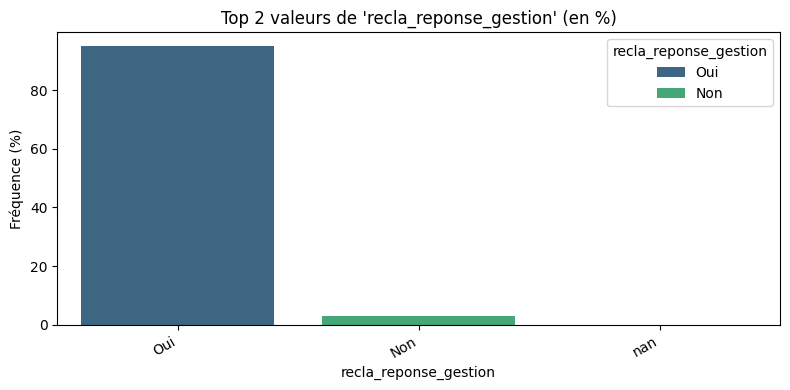

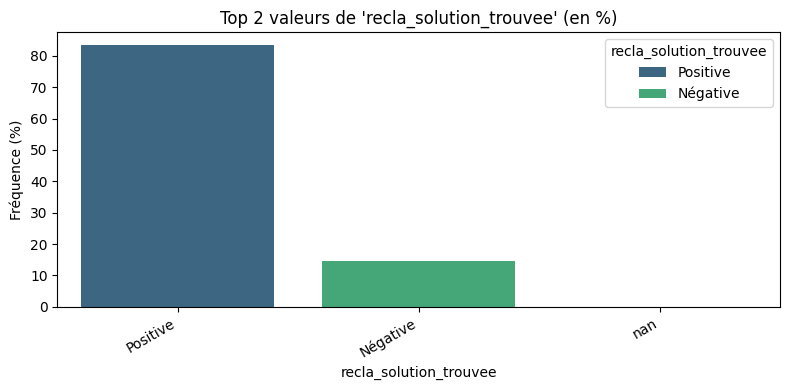

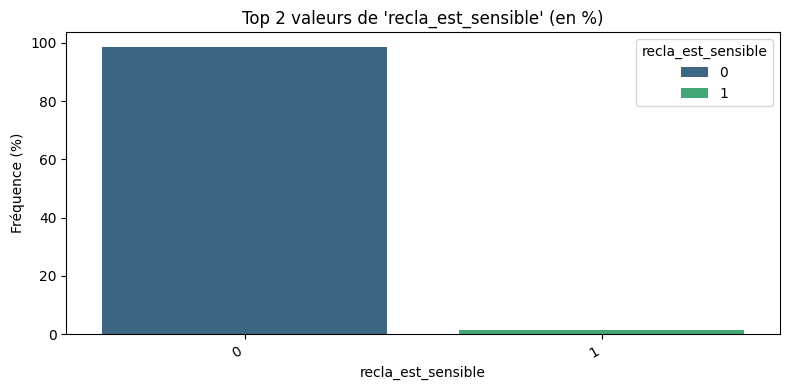

In [ ]:
plot_hist_top_k(df_reclamations, ["recla_reponse_gestion", "recla_solution_trouvee", "recla_est_sensible" ], k=2)

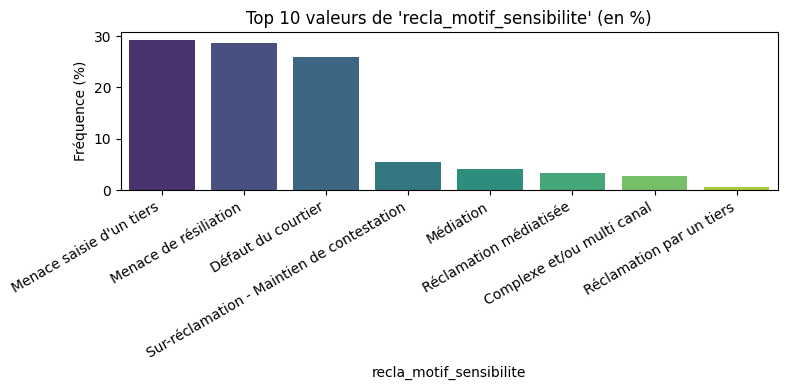

In [ ]:
plot_hist_top_k(df_reclamations[df_reclamations["recla_est_sensible"]==1], ["recla_motif_sensibilite"], k=10)

In [ ]:
df_reclamations["recla_motif_sensibilite"].unique()

array([nan, 'Menace de résiliation', "Menace saisie d'un tiers",
       'Défaut du courtier', 'Sur-réclamation - Maintien de contestation',
       'Réclamation médiatisée', 'Médiation',
       'Complexe et/ou multi canal', 'Réclamation par un tiers'],
      dtype=object)

On remarque un très faible nombre de réclamations pour motif sensible, mais sur ces réclamations sensibles, il y a une information ***menace de résiliation*** très importante pour l'étude.

D'autre part, peu de réclamation sont non résolues mais celles non résolues ou non prises en charge, mais celles qui le sont peuvent nous aider dans l'étude. 

On crée plusieurs colonnes sur la sensibilité des réclamations:
- *recla_sensible_resiliation* qui indique le nombre de réclamations sensibles du fait d'une menace de résiliation
- *recla_sensible_tiers* qui indique le nombre de réclamations sensibles du fait d'une menace saisie d'un tiers
- *recla_sensible_courtier* qui indique le nombre de réclamations sensibles du fait d'un défaut courtier
- *recla_sensible_autre* qui indique le nombre de réclamations sensibles du faut d'un motif autre que ceux cités avant

On pourra alors supprimer la colonne *recla_est_sensible* 

On peut fusionner les colonnes *recla_solution_trouve* et *recla_reponse_gestion*:
- On crée une colonne *recla_non_cloturee* qui vaut le nombre de réclamations non résolues ou non prises en charge par la gestion (quand recla_solution_trouve vaut 0 ou recla_reponse_gestion vaut 0)


**Résumé global de la méthode d'aggrégation sur réclamations**:

Pour avoir 1 ligne par code_client: 
- Créer une colonne *recla_nombre* qui compte le nombre de réclamations faites par le client dans l'année
- Créer une colonne par valeurs de *recla_theme*: dans cette colonne, la valeurs des  lignes associées au client_code est le *recla_motif* ou liste de *recla_motif* si le client a fait plusieurs réclamations sur le même thème dans l'année
- La colonne *recla_canal_entrant_principale* indique le canal sur lequel le client a fait la majorité de ses demandes
- La colonne *recla_canal_entrant_secondaire* indique le deuxième canal le plus utilisé par le client
- La colonne *recla_initiateur_client* compte le nombre de réclamation à l'initiative du client (ou d'un autre adhérent)
- Trois colonnes *recla_sensible_resiliation*, *recla_sensible_tiers* , *recla_sensible_courtier* et *recla_sensible_autre*  qui indiquent le nombre de réclamations sensibles pour chacun des motifs précisés.
- La colonne *recla_non_cloturee* qui indique le nombre de réclamations pour lesquelles une solution n'a pas été trouvée ou non prises en charge par la gestion.
- La colonne *recla_date_reception* : contient la date de réception ou une liste des date de réception (dans le cas où le client a fait plusieurs réclamations dans l'année)
- Les colonnes *recla_delais_court*, *recla_delais_moyen*, *recla_delais_long* qui comptent le nombre de réclamations pour chaque délais de réponse 


In [ ]:
# Data already loaded from setup cell, no need to reload
# If you need fresh data:
# consommations, impayes, interactions, portefeuille, reclamations = data_loading("training")
# df_reclamations = reclamations

df_reclamations["recla_motif"].unique()

array(['Couverture et fonctionnement de la garantie',
       'Valeur non référencée', 'Délai de traitement',
       'Demandes de compléments / pièces', 'Dysfonctionnement interne',
       'Montant des remboursements / Indemnités',
       'Contestation cotisation', 'Frais',
       'Modification contractuelle imposée',
       'Conditions particulières de souscription', "Défaut d'un tiers",
       'Date de radiation', 'Garantie assistance', nan,
       'Qualité de la réponse', "Qualité de l'accueil",
       'Défaut du courtier'], dtype=object)

In [ ]:
df_reclamations[[column for column in df_reclamations.columns if (column.startswith("recla_motif")) and (column !="recla_motif")]].value_counts

<bound method DataFrame.value_counts of                  recla_motif_acpr   recla_motif_sensibilite
0              Gestion du contrat                       NaN
1              Gestion du contrat                       NaN
2              Gestion du contrat                       NaN
3              Gestion du contrat                       NaN
4              Gestion du contrat                       NaN
...                           ...                       ...
11040          Gestion du contrat                       NaN
11041          Gestion du contrat  Menace saisie d'un tiers
11042  Sinistre / Prise en charge                       NaN
11043          Gestion du contrat                       NaN
11044          Gestion du contrat                       NaN

[11045 rows x 2 columns]>

In [ ]:
def aggregation_reclamations(df_reclamations):
    """
    Agrège les réclamations par client_code avec création d’indicateurs
    (motifs, canaux, sensibilité, initiateur, délais…) selon la méthode présentée dans
    le notebook "reclamation_aggregation.ipynb"

    Arg: 
    df_reclamations: DataFrame, contient le fichier des réclamations non aggrégé

    Returns: 
    df_agg: DataFrame, fichier des réclamations aggrégé
    """

    # ============================================================
    # ÉTAPE 1 — Nombre total de réclamations par client
    # ============================================================
    df_agg = (
        df_reclamations
        .groupby("client_code")
        .agg(recla_nombre=("client_code", "count"))
        .reset_index()
    )

    # ============================================================
    # ÉTAPE 2 — Colonnes sur motifs principaux & canaux principal/secondaire
    # ============================================================
    motifs = df_reclamations["recla_motif"].dropna().unique()
    
    #One hot encoding of motif columns, and creation of recla_motif_Autre for non top5 motif
    df_reclamations=pd.get_dummies(df_reclamations, columns=["recla_motif"], dtype=int) 
    colonnes_motif = [c for c in df_reclamations.columns if (c.startswith("recla_motif_")) & (c not in ["recla_motif_acpr","recla_motif_sensibilite"])]
    top5 = df_reclamations[colonnes_motif].sum().sort_values(ascending=False).head(5).index.tolist()
    autres = list(set(colonnes_motif) - set(top5))
    df_reclamations["recla_motif_Autre"] = df_reclamations[autres].sum(axis=1)
    colonnes_motif =  top5 + ["recla_motif_Autre","client_code"]
    df_motifs = df_reclamations.groupby("client_code")[top5 + ["recla_motif_Autre"]].sum().reset_index()

    # Canal principal (mode)
    canal_principal = (
        df_reclamations
        .groupby("client_code")["recla_canal_entrant"]
        .agg(lambda x: x.value_counts().idxmax())
        .rename("recla_canal_entrant_principale")
    )

    # Canal secondaire (2e mode)
    def second_mode(x):
        counts = x.value_counts()
        return counts.index[1] if len(counts) > 1 else None

    canal_secondaire = (
        df_reclamations
        .groupby("client_code")["recla_canal_entrant"]
        .agg(second_mode)
        .rename("recla_canal_entrant_secondaire")
    )

    # Fusion des résultats étape 2
    df_agg = (
        df_agg
        .merge(df_motifs, on="client_code", how="left")
        .merge(canal_principal, on="client_code", how="left")
        .merge(canal_secondaire, on="client_code", how="left")
    )

    # ============================================================
    # ÉTAPE 3 — Réclamations sensibles
    # ============================================================
    motif_resiliation = ["Menace de résiliation"]
    motif_tiers = ["Menace saisie d'un tiers"]
    motif_courtier = ["Défaut du courtier"]
    motif_autre = [
        'Sur-réclamation - Maintien de contestation',
        'Réclamation médiatisée',
        'Médiation',
        'Complexe et/ou multi canal',
        'Réclamation par un tiers'
    ]

    df_reclamations["recla_sensible_resiliation"] = df_reclamations["recla_motif_sensibilite"].isin(motif_resiliation).astype(int)
    df_reclamations["recla_sensible_tiers"] = df_reclamations["recla_motif_sensibilite"].isin(motif_tiers).astype(int)
    df_reclamations["recla_sensible_courtier"] = df_reclamations["recla_motif_sensibilite"].isin(motif_courtier).astype(int)
    df_reclamations["recla_sensible_autre"] = df_reclamations["recla_motif_sensibilite"].isin(motif_autre).astype(int)

    df_sensible_agg = df_reclamations.groupby("client_code").agg(
        recla_sensible_resiliation=("recla_sensible_resiliation", "sum"),
        recla_sensible_tiers=("recla_sensible_tiers", "sum"),
        recla_sensible_courtier=("recla_sensible_courtier", "sum"),
        recla_sensible_autre=("recla_sensible_autre", "sum"),
    ).reset_index()

    df_agg = df_agg.merge(df_sensible_agg, on="client_code", how="left")

    # ============================================================
    # ÉTAPE 4 — Nombre de réclamations initiées par le client / adhérent
    # ============================================================
    df_reclamations["recla_initiateur_client"] = df_reclamations["recla_initiateur"].isin(
        ['Client', 'Adhérent / Participant']
    ).astype(int)

    df_initiateur = (
        df_reclamations
        .groupby("client_code")["recla_initiateur_client"]
        .sum()
        .reset_index()
    )

    df_agg = df_agg.merge(df_initiateur, on="client_code", how="left")

    # ============================================================
    # ÉTAPE 5 — Réclamations non clôturées
    # ============================================================
    df_reclamations["recla_non_cloturee"] = (
        (df_reclamations["recla_reponse_gestion"] == "Non") |
        (df_reclamations["recla_solution_trouvee"] == "Négative")
    ).astype(int)

    df_non_cloture = (
        df_reclamations
        .groupby("client_code")["recla_non_cloturee"]
        .sum()
        .reset_index()
    )

    df_agg = df_agg.merge(df_non_cloture, on="client_code", how="left")

    # ============================================================
    # ÉTAPE 6 — Liste des dates de réception
    # ============================================================
    df_dates = df_reclamations.groupby("client_code").agg(
        recla_date_reception=("recla_date_reception", list)
    ).reset_index()

    df_agg = df_agg.merge(df_dates, on="client_code", how="left")

    # ============================================================
    # ÉTAPE 7 — Délais court / moyen / long
    # ============================================================
    df_reclamations["recla_date_cloture"] = pd.to_datetime(df_reclamations["recla_date_cloture"])
    df_reclamations["recla_date_reception"] = pd.to_datetime(df_reclamations["recla_date_reception"])

    df_reclamations["recla_delais"] = df_reclamations["recla_date_cloture"] - df_reclamations["recla_date_reception"]
    df_reclamations["recla_delais_jours"] = df_reclamations["recla_delais"].dt.days

    df_reclamations["recla_delais_court"] = (df_reclamations["recla_delais_jours"] <= 3).astype(int)
    df_reclamations["recla_delais_moyen"] = (
        (df_reclamations["recla_delais_jours"] > 3) &
        (df_reclamations["recla_delais_jours"] <= 15)
    ).astype(int)
    df_reclamations["recla_delais_long"] = (df_reclamations["recla_delais_jours"] > 15).astype(int)

    df_delais_agg = df_reclamations.groupby("client_code").agg(
        recla_delais_court=("recla_delais_court", "sum"),
        recla_delais_moyen=("recla_delais_moyen", "sum"),
        recla_delais_long=("recla_delais_long", "sum")
    ).reset_index()

    df_agg = df_agg.merge(df_delais_agg, on="client_code", how="left")

    # ============================================================
    # FIN — Retour du dataframe agrégé final
    # ============================================================
    return df_agg


In [ ]:
#Aggregation du fichier reclamations
# df_reclamations already loaded from setup cell
df_reclamations_agg=aggregation_reclamations(df_reclamations)

### Résultats de l'aggrégation de Réclamation

In [ ]:
#Fichier initial non aggrégé
# df_reclamations already loaded from setup cell
print(len(df_reclamations.columns))
df_reclamations.columns

12


Index(['client_code', 'recla_date_reception', 'recla_date_cloture',
       'recla_initiateur', 'recla_motif_acpr', 'recla_motif', 'recla_theme',
       'recla_canal_entrant', 'recla_solution_trouvee',
       'recla_reponse_gestion', 'recla_est_sensible',
       'recla_motif_sensibilite'],
      dtype='object')

In [ ]:
print(len(df_reclamations_agg.columns))
df_reclamations_agg.columns

20


Index(['client_code', 'recla_nombre',
       'recla_motif_Couverture et fonctionnement de la garantie',
       'recla_motif_Délai de traitement',
       'recla_motif_Montant des remboursements / Indemnités',
       'recla_motif_Frais', 'recla_motif_Demandes de compléments / pièces',
       'recla_motif_Autre', 'recla_canal_entrant_principale',
       'recla_canal_entrant_secondaire', 'recla_sensible_resiliation',
       'recla_sensible_tiers', 'recla_sensible_courtier',
       'recla_sensible_autre', 'recla_initiateur_client', 'recla_non_cloturee',
       'recla_date_reception', 'recla_delais_court', 'recla_delais_moyen',
       'recla_delais_long'],
      dtype='object')

**Résumé des colonnes présentes dans df_reclamations_agregating**
- *recla_nombre*  
  - nombre total de réclamations du client.

- Colonnes par *recla_theme*  
  - chaque colonne contient le ou les *recla_motif* associés au thème.

- *recla_canal_entrant_principale*  
  - canal le plus utilisé par le client.

- *recla_canal_entrant_secondaire*  
  - deuxième canal le plus utilisé par le client.

- *recla_initiateur_client*  
  - nombre de réclamations initiées par le client ou un adhérent.

- Réclamations sensibles  
  - *recla_sensible_resiliation*  
  - *recla_sensible_tiers*  
  - *recla_sensible_courtier*  
  - *recla_sensible_autre*  
  → nombre de réclamations sensibles par catégorie.

- *recla_non_cloturee*  
  - nombre de réclamations non prises en charge par la gestion ou sans solution trouvée.

- *recla_date_reception*  
  - la date (ou la liste de dates) de réception des réclamations.

- Délais de traitement  
  - *recla_delais_court* (≤ 3 jours)  
  - *recla_delais_moyen* (4–15 jours)  
  - *recla_delais_long* (> 15 jours)  
  → nombre de réclamations par tranche de délai.
